In [1]:
import cv2 as cv 
import numpy as np 
import matplotlib.pyplot as plt

In [5]:
def load_image(): 
    blank_image = np.zeros((600, 600), dtype=np.uint8)
    cv.putText(blank_image, text ='ABCDE', org=(50, 300), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=5, color=(255,255,255), thickness=25, lineType=cv.LINE_AA)
    return blank_image

In [6]:
def display_image(image, title='Image'):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    ax.imshow(image, cmap='gray')

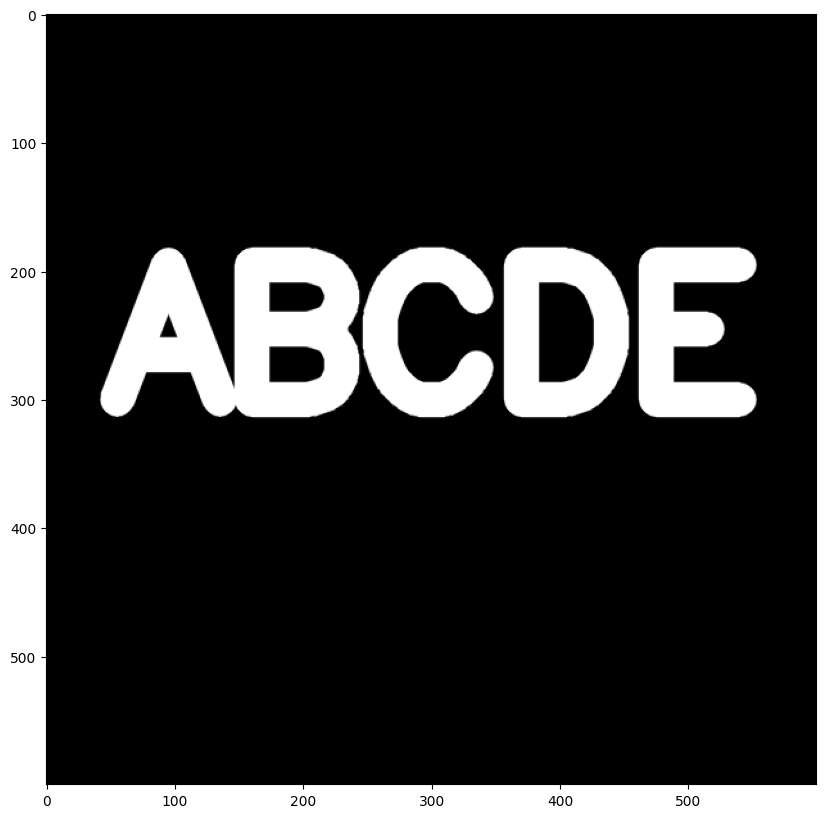

In [7]:
img = load_image()
display_image(img)

# Erosion

to differentiate between foreground and background

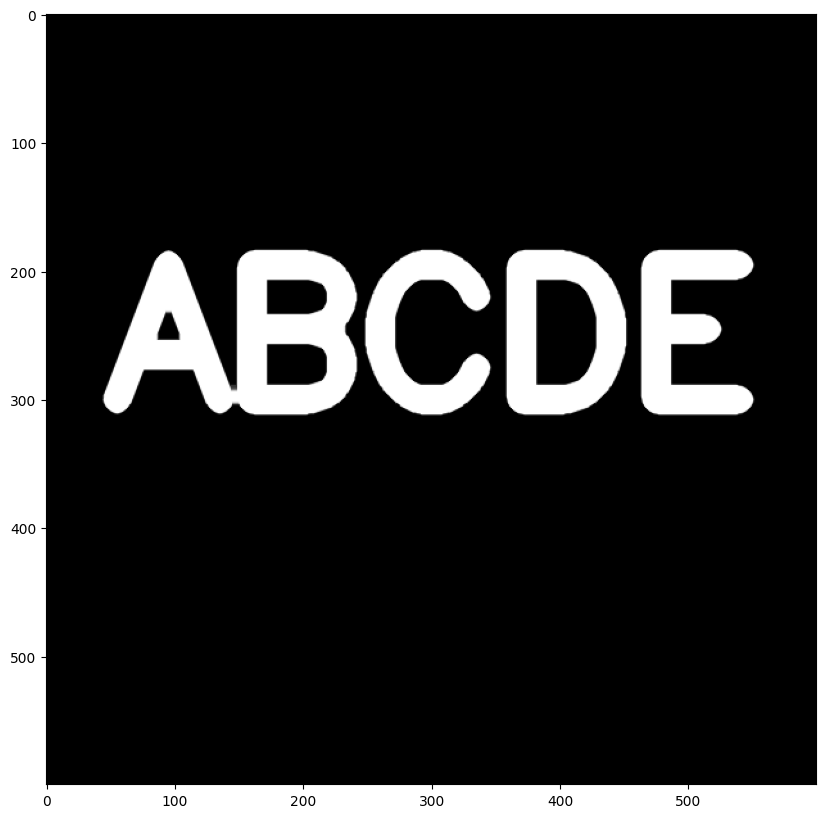

In [9]:
kernel = np.ones((5,5), dtype=np.uint8)
erosion = cv.erode(img, kernel, iterations=1)
display_image(erosion, title='Erosion')

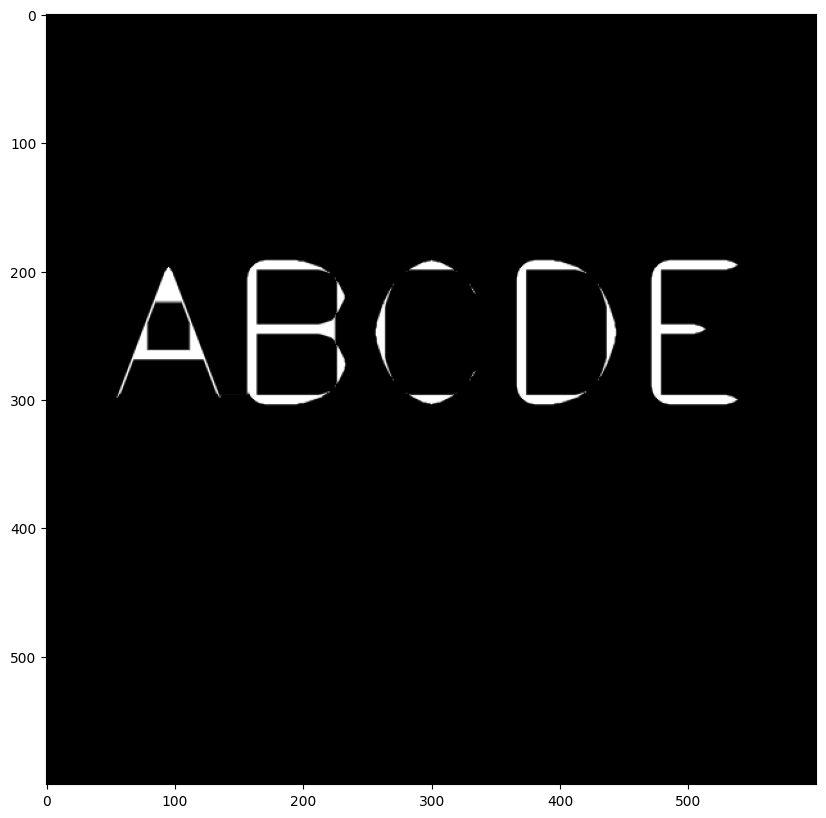

In [11]:
erosion5 = cv.erode(img, kernel, iterations=5)
display_image(erosion5, title='Erosion')

# Dilation

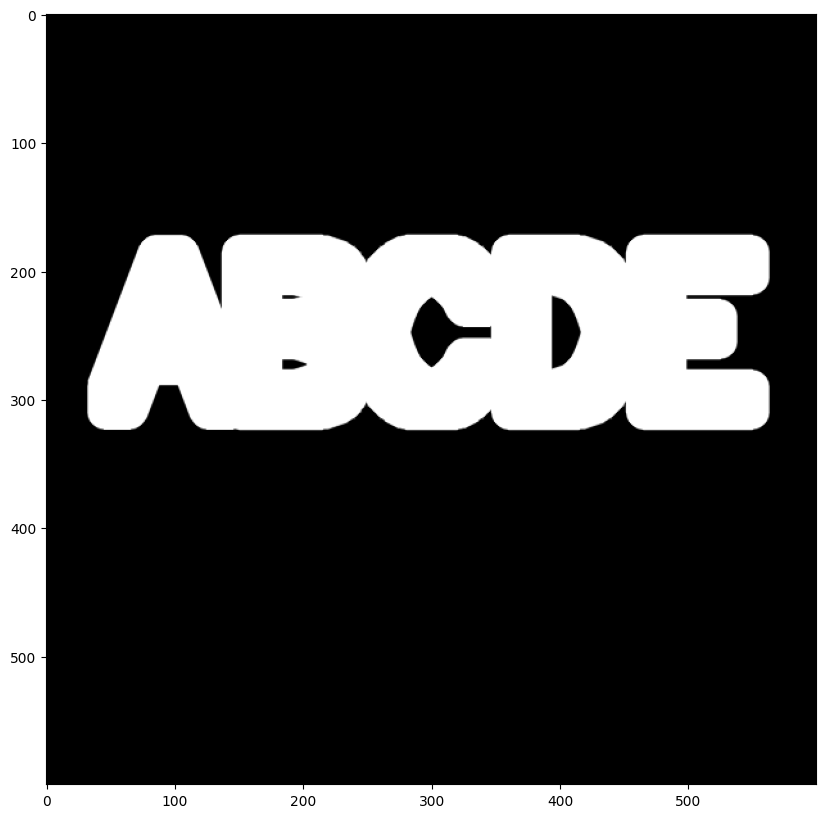

In [13]:
kernel = np.ones((5,5), dtype=np.uint8)
dilation = cv.dilate(img, kernel, iterations=5)
display_image(dilation, title='Dilation')

# Opening

erosion and then dialation

In [14]:
img = load_image()
white_noise = np.random.randint(low=0, high= 2, size=(600,600)) #adding noise to the image
white_noise


array([[1, 1, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [1, 0, 1, ..., 1, 0, 1],
       [0, 1, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 1]], shape=(600, 600), dtype=int32)

Create the noise

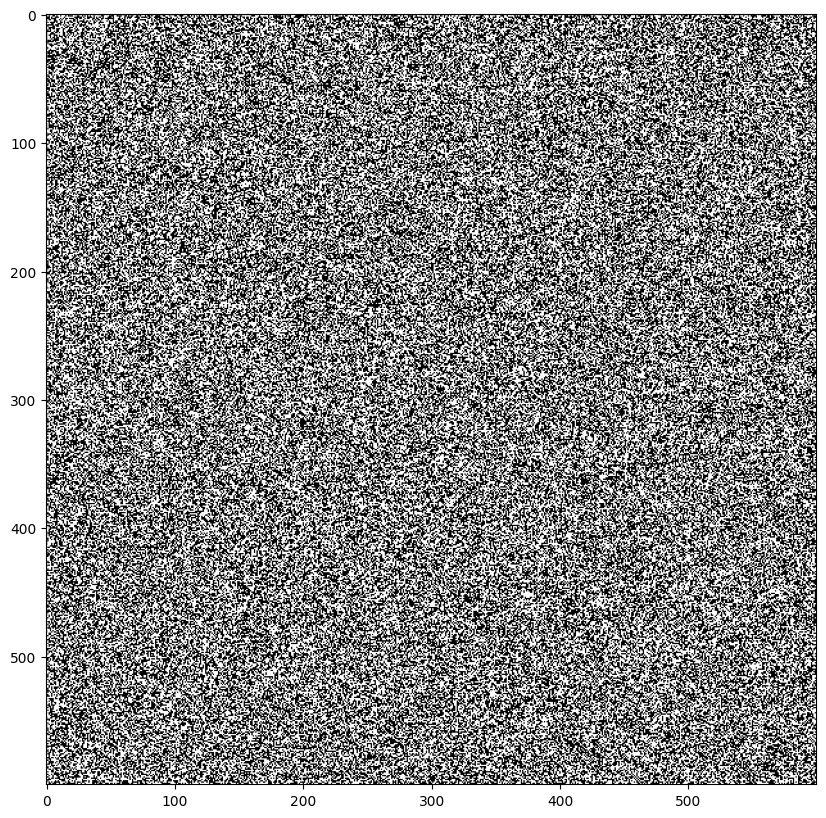

In [15]:
white_noise= white_noise * 255 #to make the noise visible
display_image(white_noise, title='White Noise')

Adding noise to the image

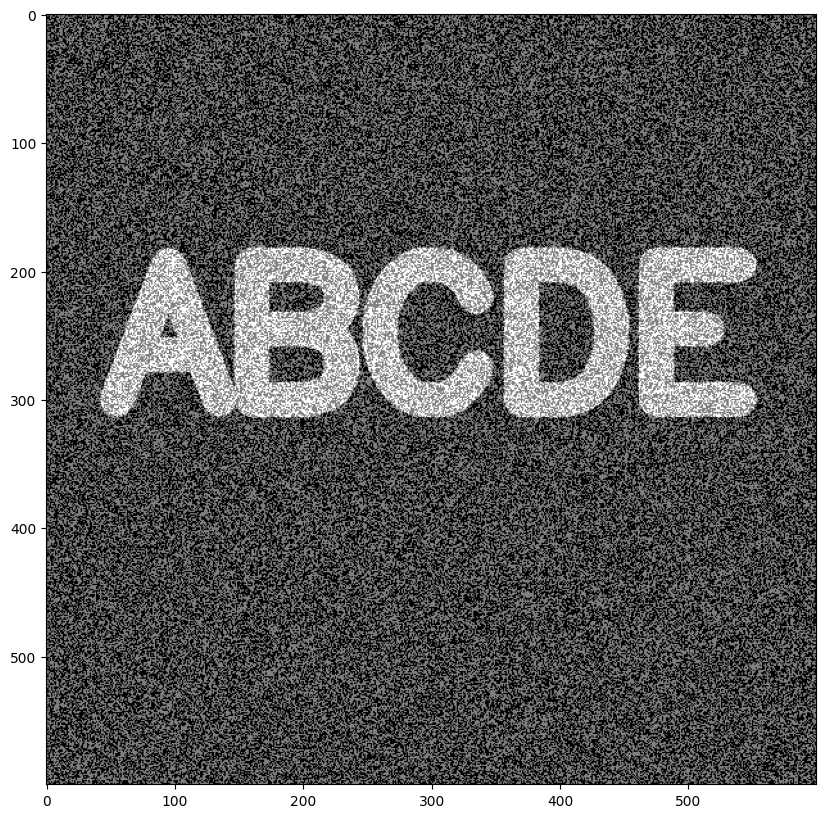

In [17]:
noise_img = white_noise + img
display_image(noise_img, title='Image with Noise')


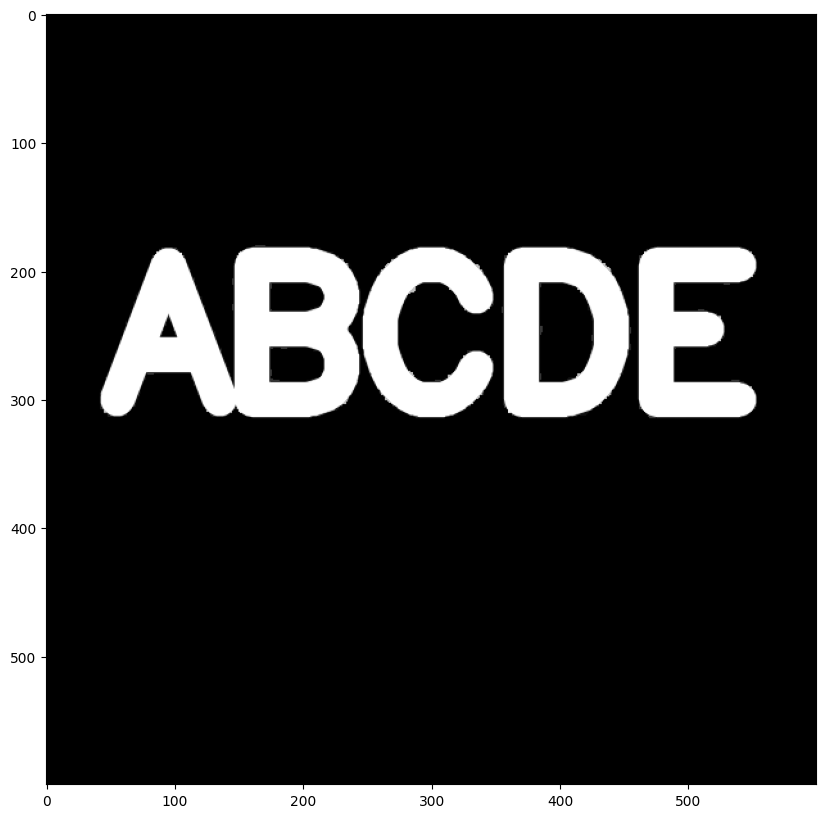

In [22]:
noise_img = noise_img.astype(np.uint8) #to make sure the image is in the correct format for morphological operations
opening = cv.morphologyEx(noise_img, cv.MORPH_OPEN, kernel) 
display_image(opening, title='Opening')


# Closing

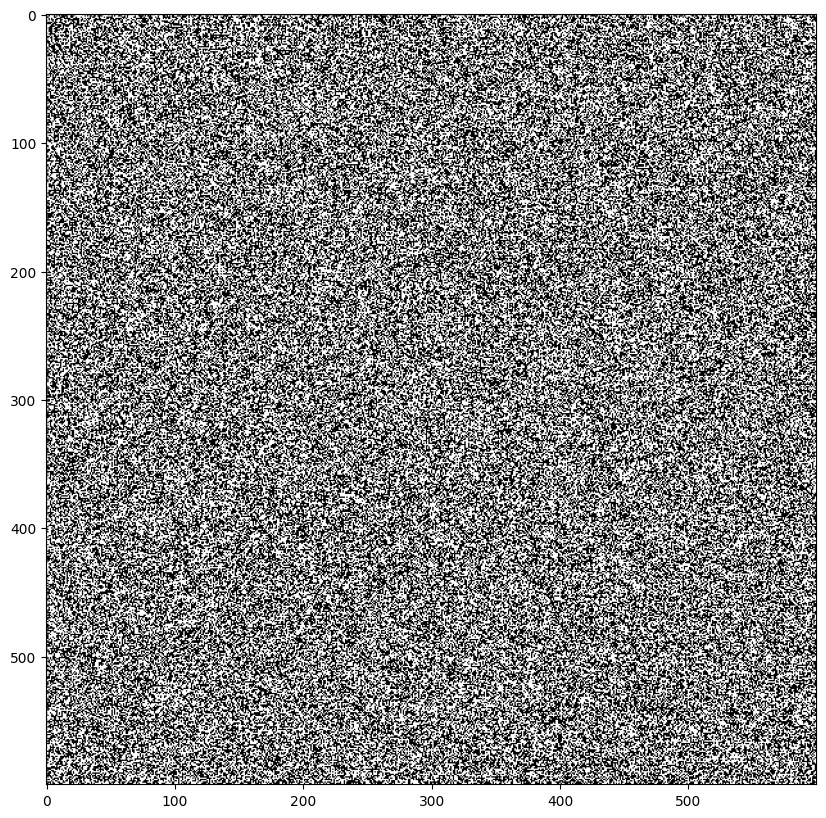

In [23]:
img = load_image()
black_noise = np.random.randint(low=0, high= 2, size=(600,600)) #adding noise to the image
black_noise = black_noise * -255 #to make the noise visible
display_image(black_noise, title='Black Noise')

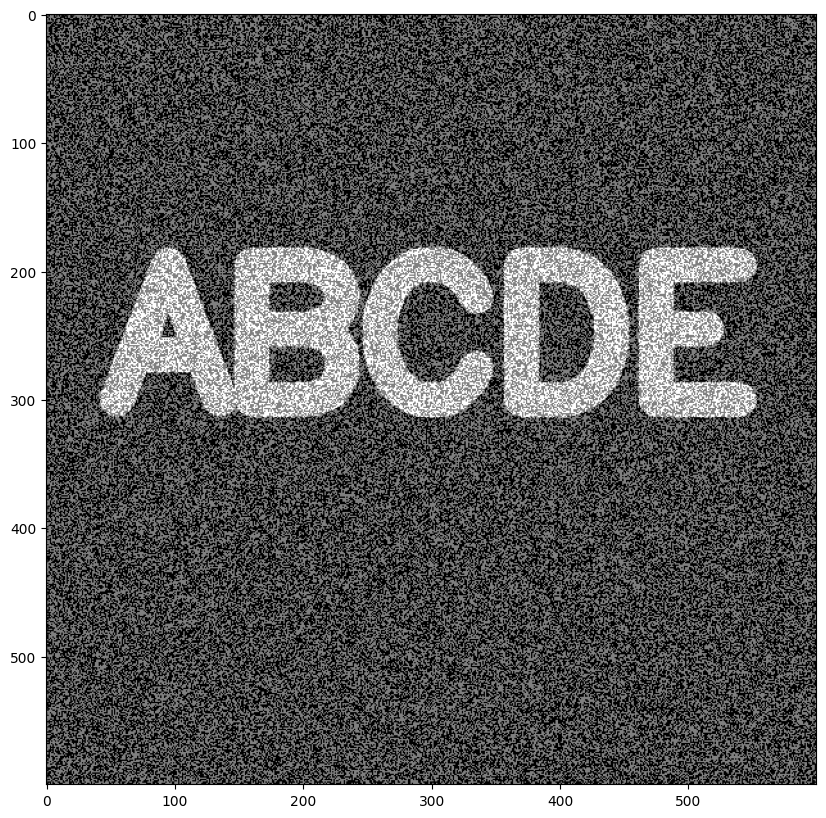

In [24]:
black_noise_img = black_noise + img
display_image(black_noise_img, title='Image with Black Noise')

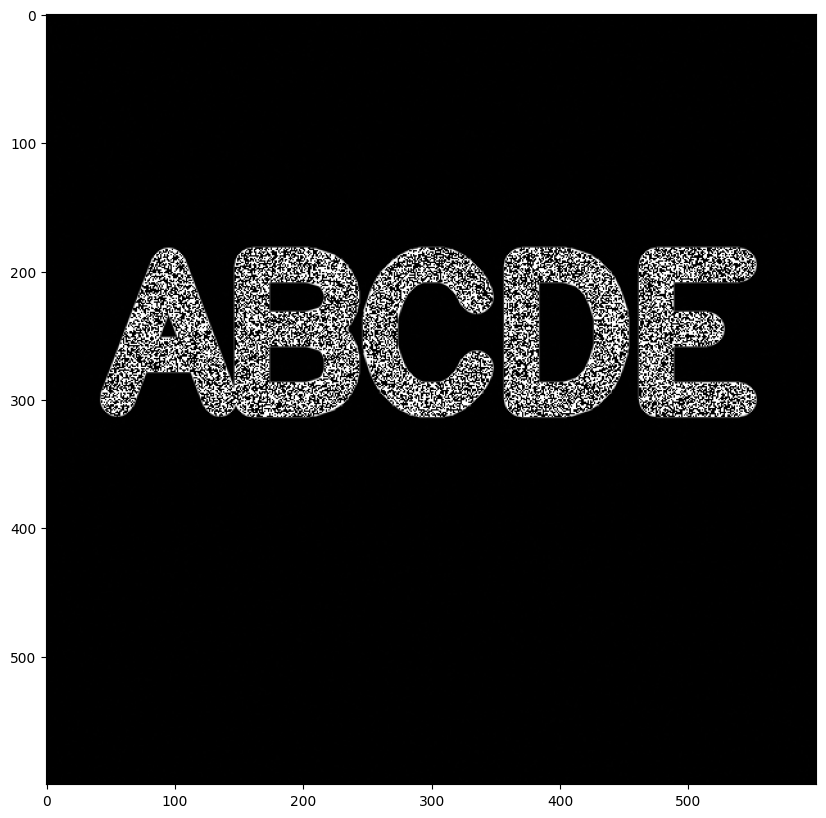

In [28]:
black_noise_img = black_noise_img.astype(np.uint8) #to make sure the image is in the correct format for morphological operations
black_noise_img[black_noise_img==-255] = 0 #to make sure the noise is black and not white
display_image(black_noise_img, title='Image with Black Noise')

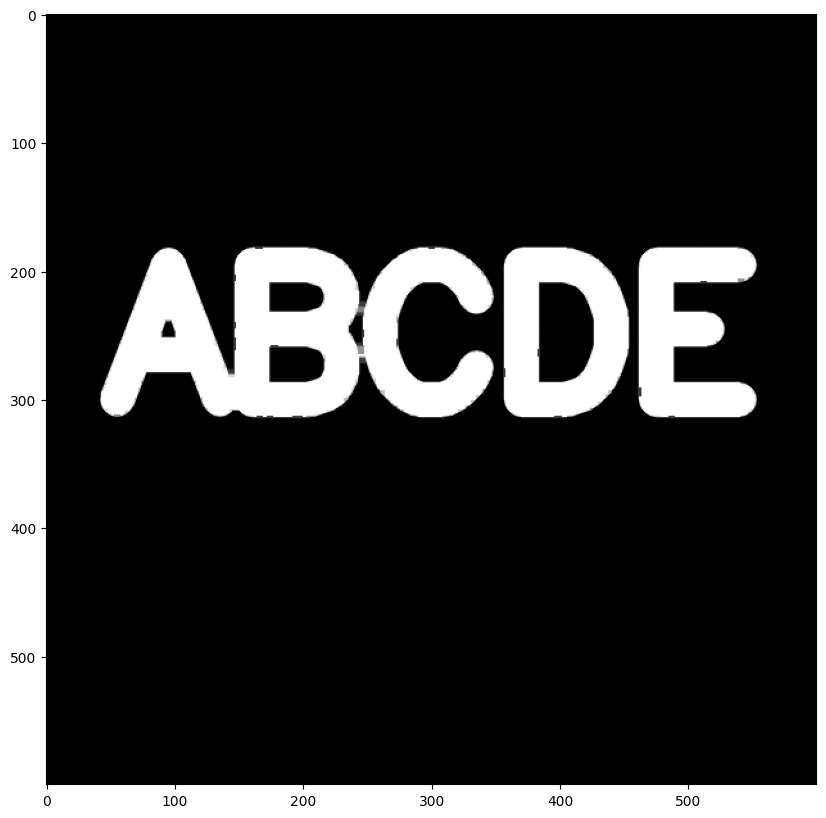

In [29]:
closing = cv.morphologyEx(black_noise_img, cv.MORPH_CLOSE, kernel)
display_image(closing, title='Closing')

# Gradient 

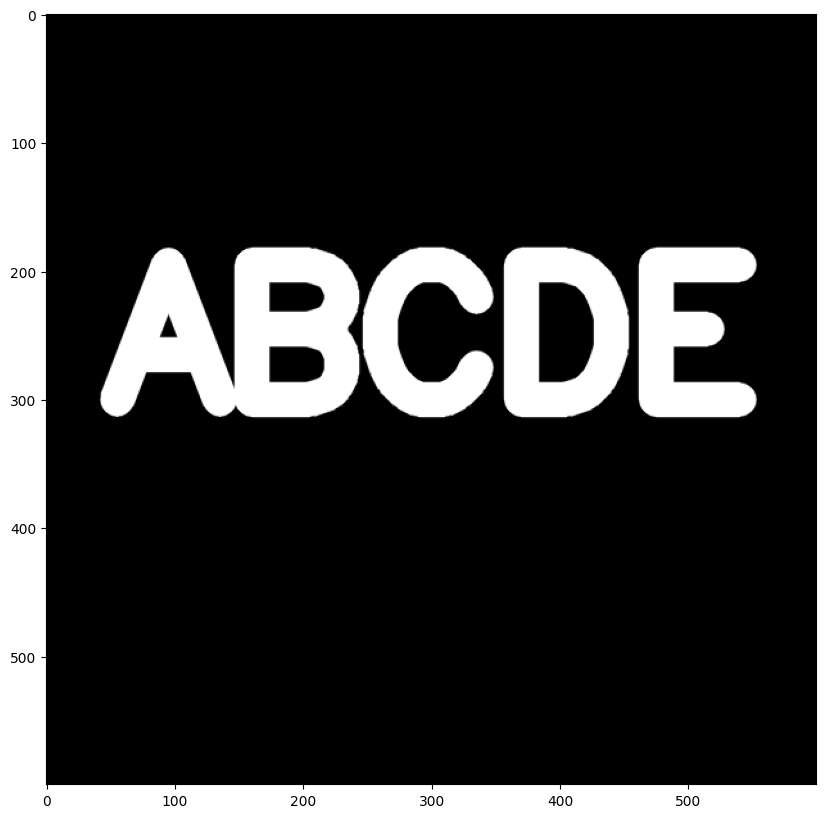

In [30]:
img = load_image()
display_image(img)

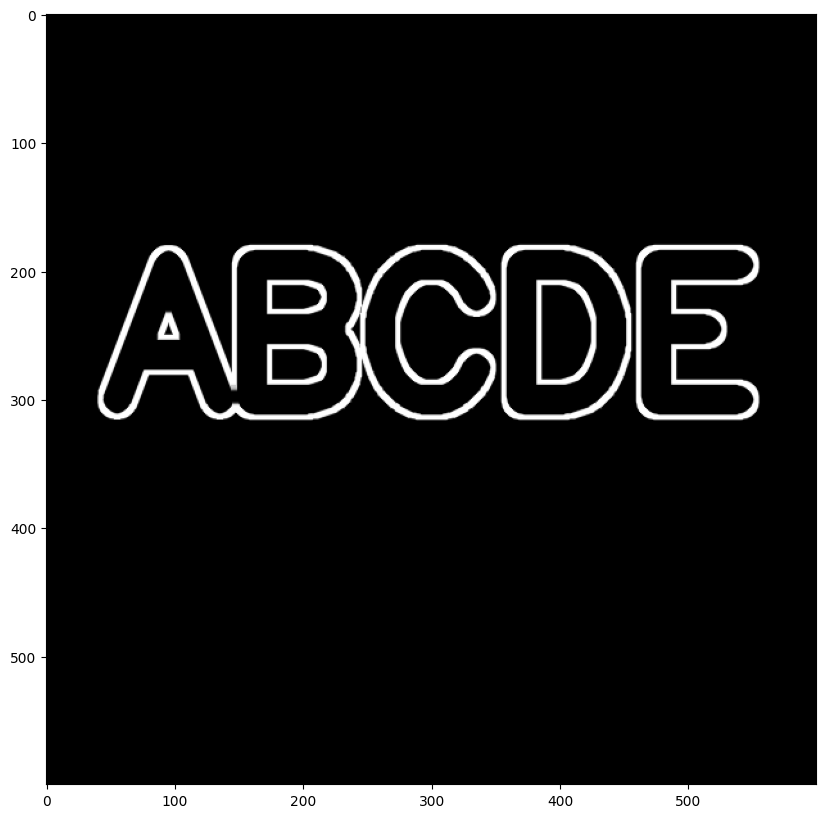

In [31]:
gradient = cv.morphologyEx(img, cv.MORPH_GRADIENT, kernel)
display_image(gradient, title='Gradient')   